Hands-On Lab: Building and Transferring a CNN       
● Step 1: Build and train a small CNN from scratch on an image dataset and record its accuracy.         
● Step 2: Add data augmentation and compare the new validation curves to the previous run.      
● Step 3: Apply transfer learning with a frozen pre-trained model (e.g. MobileNetV2) and compare accuracy and training time.        
● Step 4: Document which approach performed best and why, in Markdown.      

#### Load & inspect Dataset:

In [19]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import tensorflow as tf
from keras.utils import image_dataset_from_directory



In [20]:
IMG_SIZE = 128
BATCH_SIZE = 32

data_path = Path(r"C:\Users\Masters Computer\Desktop\VScode_For_ Python\internship\Sprint 2\Data")

print("Data folder exists:", data_path.exists())

Data folder exists: True


##### Checking the path and the data types `before loading`: `(mostly complementary)`

In [21]:
print("Folders inside Data:")

for folder in data_path.iterdir():
    if folder.is_dir():
        print(folder.name)

Folders inside Data:
Bag Classes


In [22]:
image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

def contains_class_folders(folder):
    subfolders = [
        f for f in folder.iterdir()
        if f.is_dir()
    ]

    if len(subfolders) < 2:
        return False

    folders_with_images = 0

    for subfolder in subfolders:
        has_image = any(
            file.suffix.lower() in image_extensions
            for file in subfolder.rglob("*")
            if file.is_file()
        )

        if has_image:
            folders_with_images += 1

    return folders_with_images >= 2

In [23]:
dataset_path = None

folders_to_check = [data_path] + [
    folder
    for folder in data_path.rglob("*")
    if folder.is_dir()
]

for folder in folders_to_check:
    if contains_class_folders(folder):
        dataset_path = folder
        break

print("Dataset path:", dataset_path)

Dataset path: C:\Users\Masters Computer\Desktop\VScode_For_ Python\internship\Sprint 2\Data\Bag Classes


##### `loading` the Dataset:

In [24]:
dataset = tf.keras.utils.image_dataset_from_directory(   # the full dataset 
    dataset_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

Found 15000 files belonging to 3 classes.


In [25]:
class_names = dataset.class_names  # class names(labels)

print("Classes:")
print(class_names)

print("Number of classes:", len(class_names))

Classes:
['Bag Classes', 'Paper Bag Images', 'Plastic Bag Images']
Number of classes: 3


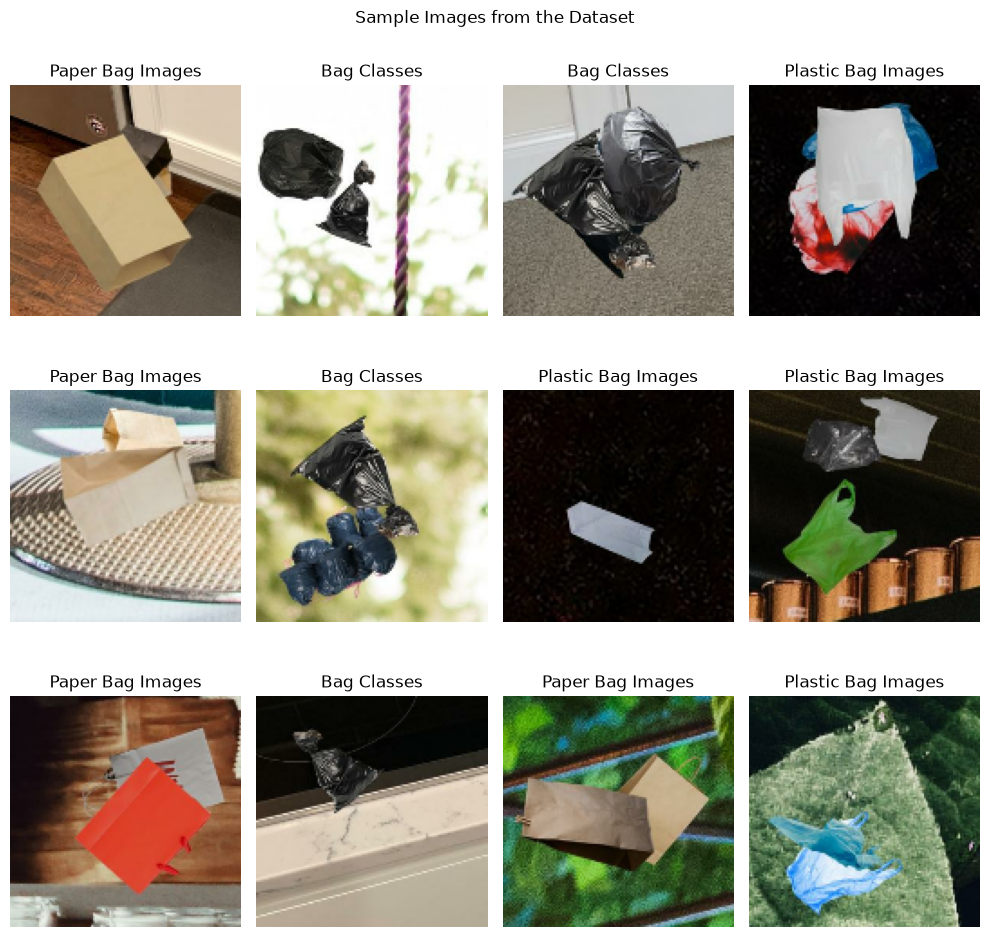

In [26]:
# visual examples from each class in the dataset 
plt.figure(figsize=(10, 10))

for images, labels in dataset.take(1):

    for i in range(min(12, len(images))):

        plt.subplot(3, 4, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            class_names[labels[i].numpy()]
        )

        plt.axis("off")

plt.suptitle("Sample Images from the Dataset")
plt.tight_layout()
plt.show()

In [27]:
print("Image count per class:")

for class_name in class_names:

    class_folder = dataset_path / class_name

    images = [
        file
        for file in class_folder.rglob("*")
        if file.is_file()
        and file.suffix.lower() in image_extensions
    ]

    print(
        f"{class_name}: {len(images)} images"
    )

Image count per class:
Bag Classes: 5000 images
Paper Bag Images: 5000 images
Plastic Bag Images: 5000 images


##### `Splitting` the Dataset train-val-test:

In [28]:
# train split
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

# validtation split
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

Found 15000 files belonging to 3 classes.
Using 12000 files for training.
Found 15000 files belonging to 3 classes.
Using 3000 files for validation.


In [29]:
# checking the split parts
print(train_ds.class_names)
print(val_ds.class_names)

['Bag Classes', 'Paper Bag Images', 'Plastic Bag Images']
['Bag Classes', 'Paper Bag Images', 'Plastic Bag Images']


In [30]:
# save class names and number of classes
class_names = train_ds.class_names

num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes) # This number determines the output layer size.

Classes: ['Bag Classes', 'Paper Bag Images', 'Plastic Bag Images']
Number of classes: 3


In [31]:
# check one Batch
for images, labels in train_ds.take(1):

    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

    break

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)


Image batch shape: (32, 128, 128, 3)        
- Means:      
32 images, 128 height, 128 width, 3 RGB channels      

##### Improve loading performance: `(complementary)`

TensorFlow can prepare the next batch while the model is training on the current one.

In [32]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch( buffer_size= AUTOTUNE)

val_ds = val_ds.prefetch( buffer_size= AUTOTUNE)

#### CNN From Scratch:

Typicaly CNN stacks (convolution + pooling) blocks to extract features, then flattens the result and feeds it into 
dense layers.

In [33]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling

##### Model

Input               
↓                 
`Rescaling`            
↓                 
Conv2D 32           
↓                   
MaxPool            
↓                  
Conv2D 64          
↓                 
MaxPool           
↓                 
Flatten              
↓                   
Dense 64          
↓                  
Softmax output     
                 

The `convolution` layers `extract features`.        

 The `pooling` layers `shrink the feature maps`.   
      
 The `dense` layers use those extracted features to `classify the image`.       

In [42]:
model = Sequential([
    
    Rescaling( 1./255  ,  input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    # for normalizing the images
    # RGB pixels are originally roughly (0-255)
    # this converts them to (0-1), which is easier for NN optimization.
    
    
    Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)), 
    # 32 different filters.
    # each filter is 3×3 .
    # each filter learns a different visual pattern.
    
    MaxPooling2D((2,2)),
    # takes a small 2×2 area and keeps only the strongest value.
    # reduces the image representation and computation while retaining strong features.
    
    Conv2D(64, (3,3), activation="relu"),
    # Why increase: 32 -> (deeper block) 64 ?
    # Earlier layers usually learn simpler patterns such as edges.
    # Deeper layers combine them into more complex features such as: corners, textures, shapes, object parts.
    
    MaxPooling2D((2,2)),
    
    Flatten(),
    # Convert extracted features for classification.
    # assume CNN has produced several 2D feature maps,
    # Flatten() turns them into a one long vector. so a normal dense layer can use them.
    
    Dense(64, activation="relu"),
    # combines the extracted CNN features for the final classification decision.
    
    Dense(len(dataset.class_names), activation="softmax"), 
    # len(dataset.class_names) gives the number of classes
    # since we have more than 2 image categories, it's a `multiclass classification problem``.
    # `Softmax` gives probabilities that sum to 1, Then the class with the highest probability wins.
    
])



c:\Users\Masters Computer\Desktop\VScode_For_ Python\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Masters Computer\Desktop\VScode_For_ Python\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,118,155 (42.41 MB)

 Trainable params: 3,706,051 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,412,104 (28.27 MB)

In [35]:
# compile
model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy", # since our labels wont look like a matrix it is better to use this. 
    metrics = ["accuracy"]
)


In [37]:
# fit (train)
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 15
)

Epoch 1/15


c:\Users\Masters Computer\Desktop\VScode_For_ Python\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


375/375 ━━━━━━━━━━━━━━━━━━━━ 71s 181ms/step - accuracy: 0.7650 - loss: 0.5582 - val_accuracy: 0.8617 - val_loss: 0.3795
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 58s 153ms/step - accuracy: 0.8838 - loss: 0.3081 - val_accuracy: 0.8783 - val_loss: 0.3114
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 44s 118ms/step - accuracy: 0.9103 - loss: 0.2378 - val_accuracy: 0.8950 - val_loss: 0.2934
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 44s 118ms/step - accuracy: 0.9401 - loss: 0.1639 - val_accuracy: 0.9077 - val_loss: 0.2696
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 43s 116ms/step - accuracy: 0.9596 - loss: 0.1134 - val_accuracy: 0.9053 - val_loss: 0.2792
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 43s 115ms/step - accuracy: 0.9686 - loss: 0.0895 - val_accuracy: 0.9110 - val_loss: 0.3132
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 44s 117ms/step - accuracy: 0.9767 - loss: 0.0714 - val_accuracy: 0.9127 - val_loss: 0.3446
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 46s 123ms/step - accuracy: 0.9793 - loss: 0.0577 - val

The best validation performance appears to occur before the final epoch, so training for all 15 epochs is unnecessary.

##### plots:

- Loss plot

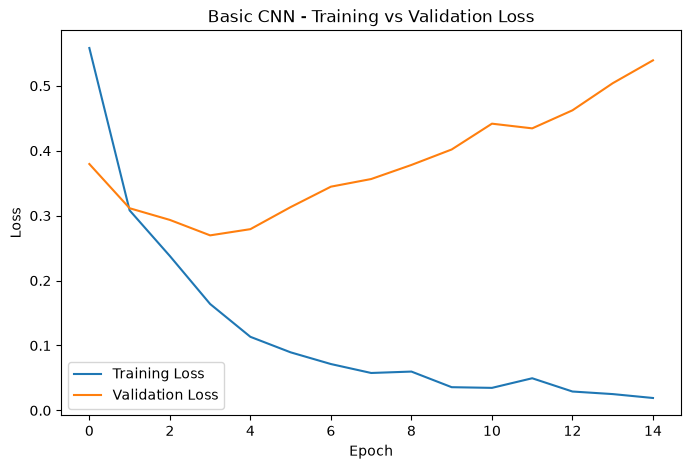

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot( history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Basic CNN - Training vs Validation Loss")
plt.legend()

plt.show()

It is showing a clear overfitting pattern as training loss decreases validation loss increases.

- Acuuracy plot

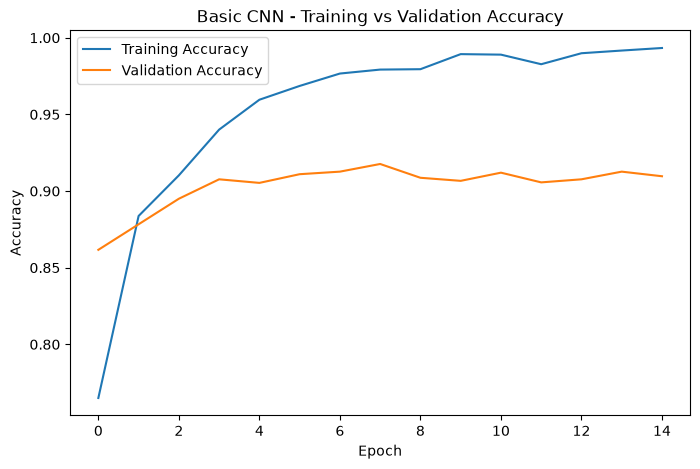

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
history.history["accuracy"], label="Training Accuracy")

plt.plot( history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Basic CNN - Training vs Validation Accuracy")
plt.legend()

plt.show()

##### Basic CNN Results

The training accuracy increases to approximately 99%, while validation accuracy remains around 91%.     
 At the same time, training loss continues to decrease but validation loss begins to increase.      

This indicates `overfitting`.       
 The CNN is learning the training images very well, but after several epochs it starts fitting details specific to the training set rather than improving its performance on unseen images.

#### After Data Augmentation

 **Data augmentation**      
  Artificially expands the dataset by applying random transformations       
  — flips, rotations, zooms, shifts —       
   so the network sees more varied examples and generalizes better.     

In [43]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom


##### Model:

Same Basic CNN + Augmentation

In [ ]:
aug_model = Sequential([
    
    # augmentation (must be before the concolution layers)
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
    
    Rescaling( 1./255  ,  input_shape=(IMG_SIZE, IMG_SIZE, 3)),

    Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)), 

    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation="relu"),
    
    MaxPooling2D((2,2)),
    
    Flatten(),
    
    Dense(64, activation="relu"),
    
    Dense(len(dataset.class_names), activation="softmax"), 
    
])



c:\Users\Masters Computer\Desktop\VScode_For_ Python\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Masters Computer\Desktop\VScode_For_ Python\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
aug_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,118,155 (42.41 MB)

 Trainable params: 3,706,051 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,412,104 (28.27 MB)

In [46]:
# compile
aug_model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy", # since our labels wont look like a matrix it is better to use this. 
    metrics = ["accuracy"]
)


In [48]:
# fit (train)
aug_history = aug_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 15
)

Epoch 1/15


c:\Users\Masters Computer\Desktop\VScode_For_ Python\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


375/375 ━━━━━━━━━━━━━━━━━━━━ 49s 130ms/step - accuracy: 0.8452 - loss: 0.4059 - val_accuracy: 0.8587 - val_loss: 0.3564
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 51s 137ms/step - accuracy: 0.8848 - loss: 0.3135 - val_accuracy: 0.8897 - val_loss: 0.3359
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 51s 137ms/step - accuracy: 0.9043 - loss: 0.2592 - val_accuracy: 0.9127 - val_loss: 0.2816
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 56s 150ms/step - accuracy: 0.9198 - loss: 0.2203 - val_accuracy: 0.9173 - val_loss: 0.2708
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 47s 126ms/step - accuracy: 0.9319 - loss: 0.1820 - val_accuracy: 0.9257 - val_loss: 0.2472
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 59s 158ms/step - accuracy: 0.9345 - loss: 0.1806 - val_accuracy: 0.9340 - val_loss: 0.1824
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 50s 134ms/step - accuracy: 0.9434 - loss: 0.1548 - val_accuracy: 0.9367 - val_loss: 0.1965
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 68s 180ms/step - accuracy: 0.9456 - loss: 0.1497 - val

##### plots:

- Loss plot

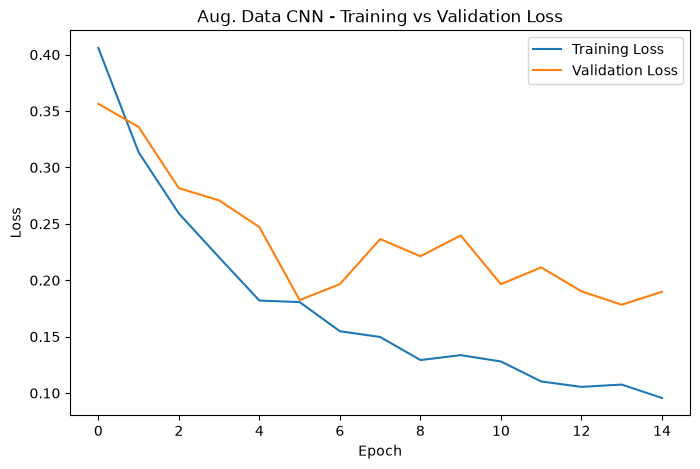

In [50]:
plt.figure(figsize=(8, 5))

plt.plot(aug_history.history["loss"], label="Training Loss")

plt.plot( aug_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Aug. Data CNN - Training vs Validation Loss")
plt.legend()

plt.show()

- Accuracy plot

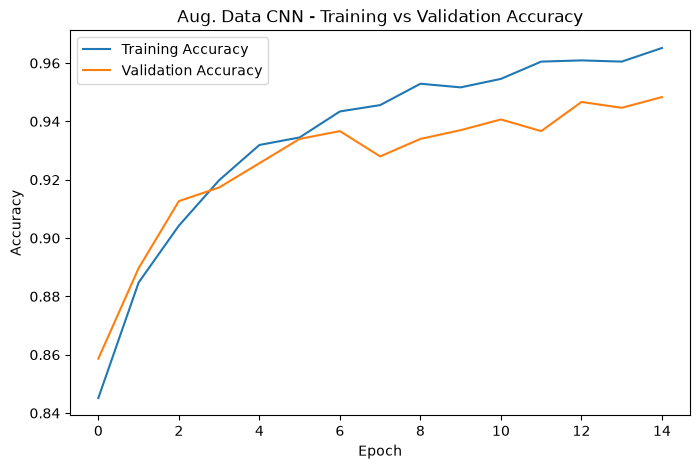

In [51]:
plt.figure(figsize=(8, 5))

plt.plot(aug_history.history["accuracy"], label="Training Accuracy")

plt.plot( aug_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Aug. Data CNN - Training vs Validation Accuracy")
plt.legend()

plt.show()

##### Results

**CNN + Data Augmentation**

Adding data augmentation reduced the overfitting seen in the basic CNN.     
 Training accuracy reached approximately 96.5%, while validation accuracy improved to about 94.8%.      

The gap between training and validation performance became much smaller, and validation loss remained relatively stable instead of continuously increasing.     

This shows that `augmentation helped the model generalize better` by exposing it to slightly modified versions of the training images.       

**Comparison with Basic CNN**

The basic CNN achieved very high training accuracy but lower validation accuracy, showing clear overfitting.
        
 After augmentation, training accuracy decreased slightly but validation accuracy improved significantly.       

This is a better result because the model performs more consistently on unseen data.        

#### Transfer Learning

 **Transfer learning**      
  Reuses a model already trained on millions of images.

We keep its learned feature-detecting layers, and        
 replace only       
the final classification layer with your own.        

In [57]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras import Sequential

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

#####  Model:

In [62]:
# Pretrained model
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    
    include_top=False, # we do not want MobileNetV2’s original ImageNet classifier, -We only want its feature extractor-
    
    weights="imagenet"
)

In [63]:
base_model.trainable = False # freeze the pre-trained feature extractor
# meaning:
# Keep the pretrained convolution weights unchanged for now.

In [64]:
transfer_model = Sequential([
    
    tf.keras.layers.Lambda(preprocess_input), # MobileNetV2 expects its inputs in a particular range.(-1 - 1). Rescalling gives (0 - 1) so it's not optimal.

    base_model,
    
    GlobalAveragePooling2D(),
    
    Dense(num_classes, activation="softmax")
])

# GlobalAveragePooling2D() converts all the feature maps from MobileNetV2
# into a compact vector without creating the huge number of parameters that Flatten() could create.

In [65]:
transfer_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [66]:
# compile
transfer_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [67]:
transfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

# only new classification head is learning.

Epoch 1/15


c:\Users\Masters Computer\Desktop\VScode_For_ Python\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(



375/375 ━━━━━━━━━━━━━━━━━━━━ 112s 278ms/step - accuracy: 0.9211 - loss: 0.2041 - val_accuracy: 0.9613 - val_loss: 0.1071
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 65s 174ms/step - accuracy: 0.9683 - loss: 0.0868 - val_accuracy: 0.9627 - val_loss: 0.0931
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 66s 175ms/step - accuracy: 0.9775 - loss: 0.0661 - val_accuracy: 0.9693 - val_loss: 0.0762
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 59s 158ms/step - accuracy: 0.9826 - loss: 0.0529 - val_accuracy: 0.9723 - val_loss: 0.0702
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 61s 162ms/step - accuracy: 0.9849 - loss: 0.0441 - val_accuracy: 0.9740 - val_loss: 0.0685
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 54s 145ms/step - accuracy: 0.9887 - loss: 0.0383 - val_accuracy: 0.9753 - val_loss: 0.0653
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 62s 166ms/step - accuracy: 0.9902 - loss: 0.0331 - val_accuracy: 0.9733 - val_loss: 0.0674
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 94s 251ms/step - accuracy: 0.9912 - loss: 0.0299 - v

##### plots:

- Loss plot

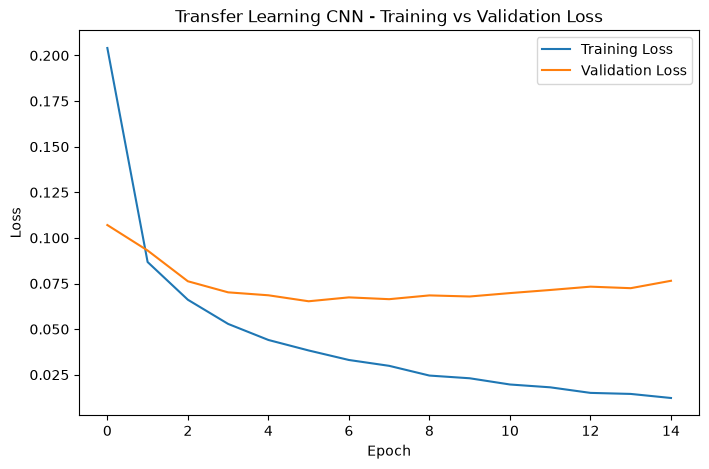

In [68]:
plt.figure(figsize=(8, 5))

plt.plot(transfer_history.history["loss"], label="Training Loss")

plt.plot( transfer_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transfer Learning CNN - Training vs Validation Loss")
plt.legend()

plt.show()

- Accuracy plot

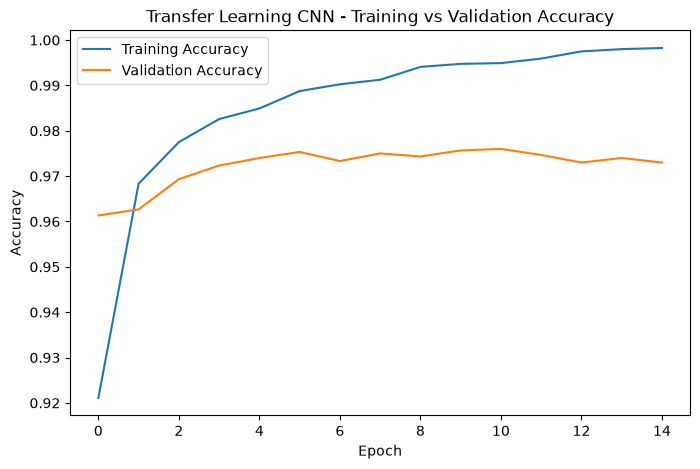

In [69]:
plt.figure(figsize=(8, 5))

plt.plot(transfer_history.history["accuracy"], label="Training Accuracy")

plt.plot( transfer_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning CNN - Training vs Validation Accuracy")
plt.legend()

plt.show()

#### Overall Results

| Model                         | Final Train Accuracy | Final Val Accuracy | Final Train Loss | Final Val Loss | Observation                 |
| ----------------------------- | -------------------: | -----------------: | ---------------: | -------------: | --------------------------- |
| Basic CNN                     |                0.993 |              0.910 |            0.019 |          0.539 | Clear overfitting           |
| CNN + Augmentation            |                0.965 |              0.948 |            0.096 |          0.190 | Better generalization       |
| MobileNetV2 Transfer Learning |            **0.998** |          **0.973** |        **0.012** |      **0.077** | Best validation performance |


#### Model Comparison

The `Basic CNN` reached very high training accuracy at approximately `99.3%`, but validation accuracy remained around `91%` while validation loss increased.    
 This showed clear **`overfitting`**.

Adding `data augmentation` reduced the gap between training and validation performance.     
 Validation accuracy improved to approximately `94.8%` and validation loss decreased significantly, showing `better generalization`.

The `MobileNetV2 transfer-learning model` achieved the **`best overall validation performance`**,       
 with approximately `97.3% validation accuracy` and a validation loss of about `0.077`.

Therefore, `transfer learning performed best` because the pretrained MobileNetV2 feature extractor already contains useful visual features and was able to adapt them effectively to the waste-image classification task.
